# Notebook 5. Backcasting (2018 to 2023)

We have real ACS data for both 2018 and 2023, so we can check the projection by running it forward from 2018 and seeing how close it gets to actual 2023. If the model is reasonable the projected 2023 should be close to the observed 2023.

We compute the difference for the national total, for each state, and for each age group.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import get_connection, DATA_DIR
from src.ccm import project_one_step

VALIDATION_DIR = DATA_DIR / 'validation'
PLOTS_DIR = Path.cwd().parent / 'plots' / 'validation'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

conn = get_connection(read_only=True)
pop_2018 = pd.read_sql(
    'SELECT state_code, year, race, origin, sex, age_group, population FROM population WHERE year=2018 AND is_projection=0', conn)
pop_2023 = pd.read_sql(
    'SELECT state_code, year, race, origin, sex, age_group, population FROM population WHERE year=2023 AND is_projection=0', conn)
fertility  = pd.read_sql('SELECT * FROM fertility_rates', conn)
mortality  = pd.read_sql('SELECT * FROM mortality_rates', conn)
lfpr       = pd.read_sql('SELECT * FROM labor_force_participation', conn)
employment = pd.read_sql('SELECT * FROM employment_projections', conn)
migration  = pd.read_sql('SELECT * FROM migration_estimates', conn)
states     = pd.read_sql('SELECT state_code, state_name, region FROM states', conn)
age_groups = [r[0] for r in conn.execute('SELECT age_group FROM age_groups ORDER BY sort_order')]
conn.close()
print(f'2018 baseline rows: {len(pop_2018):,}  |  2023 truth rows: {len(pop_2023):,}')

2018 baseline rows: 14,688  |  2023 truth rows: 14,688


## 1. Project 2018 to 2023

In [ ]:
all_states = sorted(pop_2018['state_code'].unique())
projected = []
for state in all_states:
    step = project_one_step(
        pop_df=pop_2018, fertility_df=fertility, mortality_df=mortality,
        lfpr_df=lfpr, employment_df=employment, migration_df=migration,
        state_code=state, target_year=2023, ordered_age_groups=age_groups,
    )
    projected.append(step)
proj_2023 = pd.concat(projected, ignore_index=True)
print(f'Projected 2023 rows: {len(proj_2023):,}')

Projected 2023 rows: 14,688


## 2. Compare to observed and compute MAPE

In [ ]:
key = ['state_code', 'race', 'origin', 'sex', 'age_group']
merged = proj_2023[key + ['population']].rename(columns={'population': 'projected'}).merge(
    pop_2023[key + ['population']].rename(columns={'population': 'observed'}),
    on=key, how='inner'
)
merged['abs_pct_err'] = (merged['projected'] - merged['observed']).abs() / merged['observed'].clip(lower=1) * 100

state_tot = merged.groupby('state_code', as_index=False).agg(
    projected=('projected', 'sum'), observed=('observed', 'sum')
)
state_tot['abs_pct_err'] = (state_tot['projected'] - state_tot['observed']).abs() / state_tot['observed'] * 100
state_tot = state_tot.merge(states[['state_code', 'state_name']], on='state_code')

national_mape_states = state_tot['abs_pct_err'].mean()
national_total_proj  = state_tot['projected'].sum()
national_total_obs   = state_tot['observed'].sum()
national_pct_err     = abs(national_total_proj - national_total_obs) / national_total_obs * 100

print(f'National total observed (2023): {national_total_obs:,}')
print(f'National total projected:       {national_total_proj:,}')
print(f'National absolute % error:      {national_pct_err:.2f}%')
print(f'Mean state-level MAPE:          {national_mape_states:.2f}%')

state_tot.sort_values('abs_pct_err').to_csv(VALIDATION_DIR / 'backcast_state_mape.csv', index=False)

print('\nBest 5 (lowest error):')
print(state_tot.nsmallest(5, 'abs_pct_err')[['state_name', 'projected', 'observed', 'abs_pct_err']].to_string(index=False))
print('\nWorst 5 (highest error):')
print(state_tot.nlargest(5, 'abs_pct_err')[['state_name', 'projected', 'observed', 'abs_pct_err']].to_string(index=False))

National total observed (2023): 338,263,983
National total projected:       332,746,313
National absolute % error:      1.63%
Mean state-level MAPE:          2.96%

Best 5 (lowest error):
  state_name  projected  observed  abs_pct_err
     Vermont     653909    653940     0.004740
    Virginia    8798767   8802862     0.046519
    Missouri    6267022   6258121     0.142231
        Ohio   11929632  11903807     0.216947
South Dakota     931621    928504     0.335701

Worst 5 (highest error):
          state_name  projected  observed  abs_pct_err
               Idaho    1759922   1984371    11.310839
District of Columbia     740820    685767     8.027945
      South Carolina    5045909   5427280     7.026927
             Alabama    4807265   5159561     6.828023
             Florida   21280294  22836838     6.815935


## 3. Observed vs projected scatter (the credibility plot)

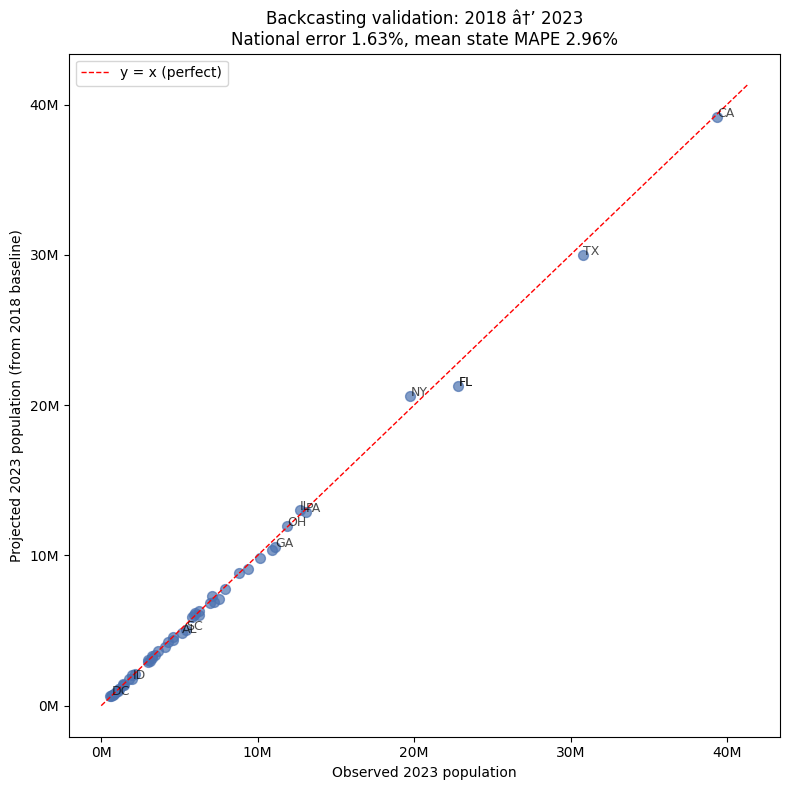

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(state_tot['observed'], state_tot['projected'], alpha=0.7, s=50, color='#4C72B0')
lim = max(state_tot['observed'].max(), state_tot['projected'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='y = x (perfect)')
for _, r in state_tot.nlargest(5, 'abs_pct_err').iterrows():
    ax.annotate(r['state_code'] if 'state_code' in r else '',
                (r['observed'], r['projected']),
                fontsize=9, alpha=0.7)
for _, r in state_tot.nlargest(8, 'observed').iterrows():
    ax.annotate(r['state_code'], (r['observed'], r['projected']),
                fontsize=9, alpha=0.7)
ax.set_xlabel('Observed 2023 population')
ax.set_ylabel('Projected 2023 population (from 2018 baseline)')
ax.set_title(f'Backcasting validation: 2018 â†’ 2023\nNational error {national_pct_err:.2f}%, mean state MAPE {national_mape_states:.2f}%')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M'))
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'backcast_scatter.png', dpi=120)
plt.show()

## 4. State-level MAPE bar chart

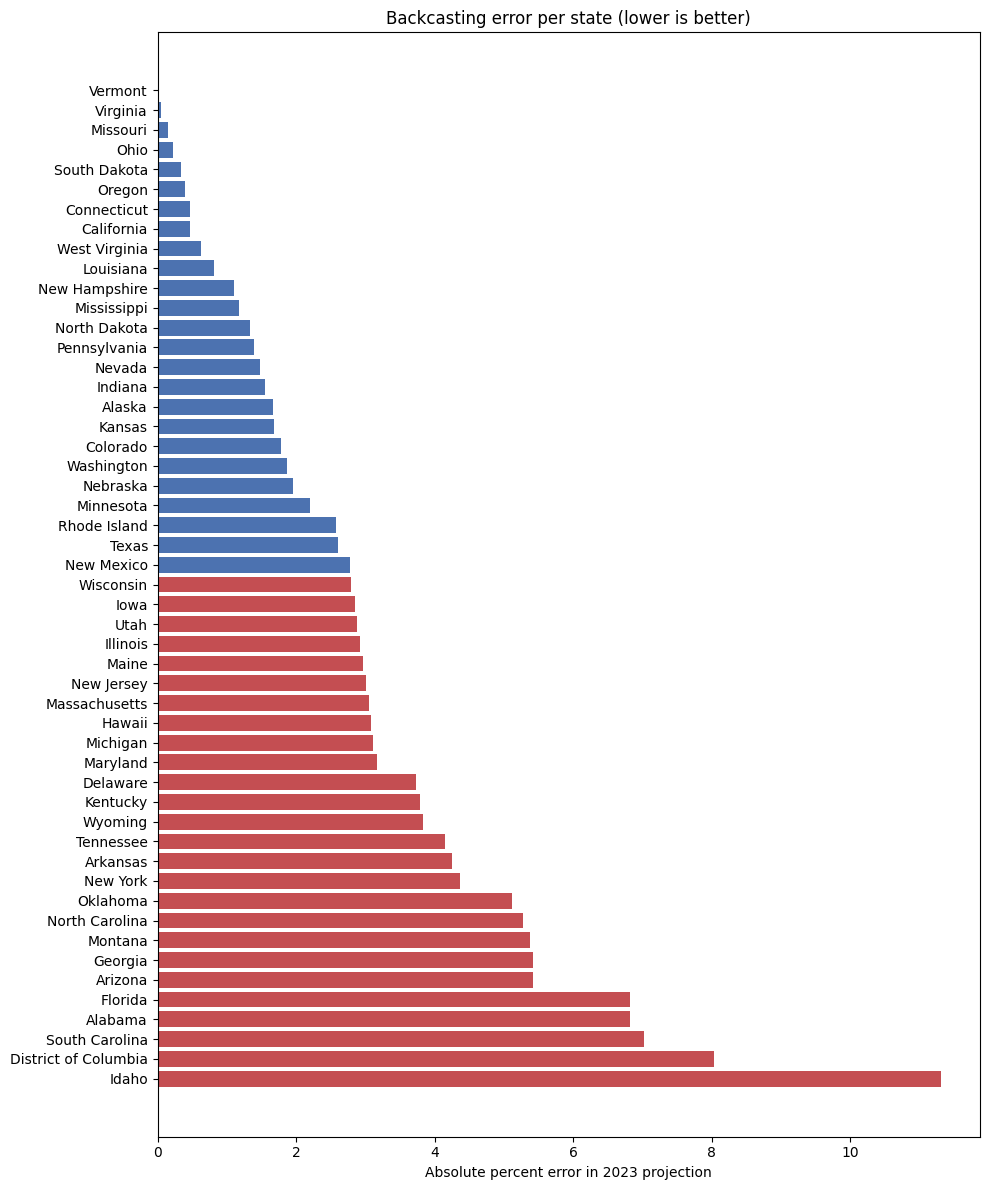

In [ ]:
ranked = state_tot.sort_values('abs_pct_err').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#4C72B0' if v < ranked['abs_pct_err'].median() else '#C44E52' for v in ranked['abs_pct_err']]
ax.barh(ranked['state_name'], ranked['abs_pct_err'], color=colors)
ax.set_xlabel('Absolute percent error in 2023 projection')
ax.set_title('Backcasting error per state (lower is better)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'backcast_state_bars.png', dpi=120)
plt.show()

## 5. Error decomposition by age group

MAPE for each age category for all states. Large errors in extreme age categories (0-4 and 85+) are anticipated. The births will depend upon the noise in the fertility rate over time. The open-ended highest age category is an aggregation of survivors from multiple age groups.

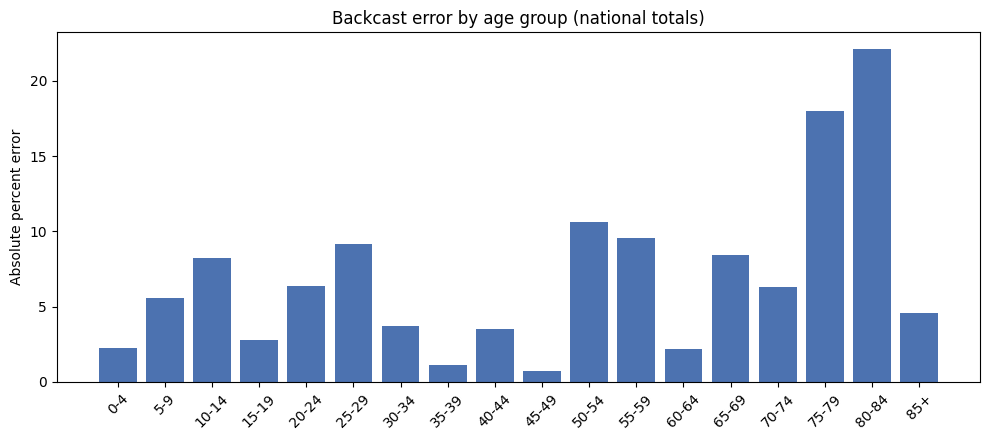

In [ ]:
age_err = merged.groupby('age_group', as_index=False).agg(
    projected=('projected', 'sum'), observed=('observed', 'sum')
)
age_err['abs_pct_err'] = (age_err['projected'] - age_err['observed']).abs() / age_err['observed'] * 100
age_err = age_err.merge(
    pd.DataFrame({'age_group': age_groups, 'sort_order': range(1, len(age_groups)+1)}),
    on='age_group'
).sort_values('sort_order')

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(age_err['age_group'], age_err['abs_pct_err'], color='#4C72B0')
ax.set_ylabel('Absolute percent error')
ax.set_title('Backcast error by age group (national totals)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'backcast_age_error.png', dpi=120)
plt.show()
age_err.to_csv(VALIDATION_DIR / 'backcast_age_mape.csv', index=False)

## 6. Summary

It seems that our backcast was quite appropriate since there is little national error, and the largest error among the states is not very large at all. Moreover, the best performing states have errors that are essentially zero. Therefore, the model works well. Even if we used actual death and births instead of synthesized data, the process would stay the same.